In [216]:
import multiprocessing as mp
import numpy as np
import numpy.typing as npt

if __name__ == "__main__":
    N_STATE = 10
    N_ITER = 200
    ALPHA = 0.3

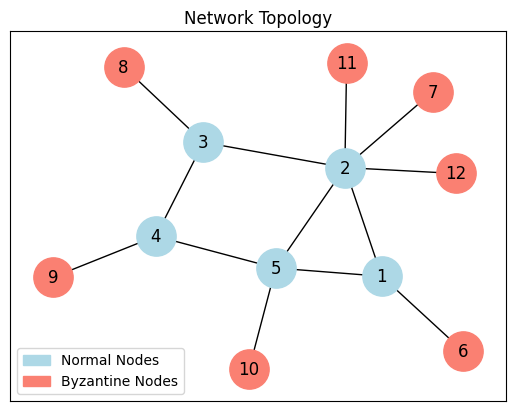

In [217]:
def graph(nodes: list[str], edges: list[tuple[str, str]]) -> None:
    from logging import basicConfig, INFO

    basicConfig(level=INFO)

    from topolink import Graph

    graph = Graph(nodes, edges)

    graph.deploy()


if __name__ == "__main__":
    # Simple case
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [("1", "2"), ("2", "3"), ("3", "4"), ("4", "5"), ("5", "1")]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10"]
    BYZANTINE_EDGES = [("1", "6"), ("2", "7"), ("3", "8"), ("4", "9"), ("5", "10")]

    # Moderate case
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("1", "6"),
    #     ("2", "7"),
    # ]
    # BYZANTINE_NODES = ["8", "9", "10"]
    # BYZANTINE_EDGES = [("3", "8"), ("4", "9"), ("5", "10")]

    # Extreme case
    NORMAL_NODES = ["1", "2", "3", "4", "5"]
    NORMAL_EDGES = [
        ("1", "2"),
        ("2", "3"),
        ("3", "4"),
        ("4", "5"),
        ("5", "1"),
        ("2", "5"),
    ]
    BYZANTINE_NODES = ["6", "7", "8", "9", "10", "11", "12"]
    BYZANTINE_EDGES = [
        ("1", "6"),
        ("2", "7"),
        ("3", "8"),
        ("4", "9"),
        ("5", "10"),
        ("2", "11"),
        ("2", "12"),
    ]

    # Conservative case
    # NORMAL_NODES = ["1", "2", "3", "4", "5", "6", "7"]
    # NORMAL_EDGES = [
    #     ("1", "2"),
    #     ("2", "3"),
    #     ("3", "4"),
    #     ("4", "5"),
    #     ("5", "1"),
    #     ("1", "6"),
    #     ("5", "6"),
    #     ("3", "7"),
    #     ("4", "7"),
    # ]
    # BYZANTINE_NODES = []
    # BYZANTINE_EDGES = []

    NODES = NORMAL_NODES + BYZANTINE_NODES
    EDGES = NORMAL_EDGES + BYZANTINE_EDGES

    N_NORMAL = len(NORMAL_NODES)
    N_BYZANTINE = len(BYZANTINE_NODES)
    N_NODES = N_NORMAL + N_BYZANTINE

    import matplotlib.pyplot as plt
    import networkx as nx

    fig, ax = plt.subplots()
    ax.set_title("Network Topology")

    G = nx.Graph()
    G.add_nodes_from(NODES)
    G.add_edges_from(EDGES)

    pos = nx.spring_layout(G, seed=11, k=0.8)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=NORMAL_NODES,
        node_color="lightblue",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=BYZANTINE_NODES,
        node_color="salmon",
        node_size=800,
        ax=ax,
    )

    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    import matplotlib.patches as mpatches

    blue_patch = mpatches.Patch(color="lightblue", label="Normal Nodes")
    red_patch = mpatches.Patch(color="salmon", label="Byzantine Nodes")

    ax.legend(handles=[blue_patch, red_patch], loc="lower left")

In [218]:
def byzantine_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    byz_type = "constant"
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import seed, uniform
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        laplacian = nh.laplacian(x[k])

        if byz_type == "constant":
            x[k + 1] = x[k]
        elif byz_type == "random":
            x[k + 1] = uniform(lower_bound, upper_bound, n_state)
        elif byz_type == "disturbance":
            disturbance = uniform(-1.0, 1.0, n_state)
            x[k + 1] = x[k] - laplacian * alpha + disturbance
        elif byz_type == "coordination":
            disturbance = np.zeros(n_state)
            disturbance[0] = uniform(lower_bound, upper_bound)
            x[k + 1] = x[k] - laplacian * alpha + disturbance

    return x

In [219]:
def baseline_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        x[k + 1] = x[k] - nh.laplacian(x[k]) * alpha

    return x


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        baseline_results = {
            i: pool.apply_async(baseline_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        baseline_data = {i: result.get() for i, result in baseline_results.items()}
        byzantine_data = {i: result.get() for i, result in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 158.125.191.134:46109
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '8' joined graph 'default' from 158.125.191.134:45639.
INFO:topolink.graph:Node '10' joined graph 'default' from 158.125.191.134:44651.
INFO:topolink.graph:Node '4' joined graph 'default' from 158.125.191.134:45381.
INFO:topolink.graph:Node '11' joined graph 'default' from 158.125.191.134:46017.
INFO:topolink.graph:Node '2' joined graph 'default' from 158.125.191.134:45633.
INFO:topolink.graph:Node '6' joined graph 'default' from 158.125.191.134:45853.
INFO:topolink.graph:Node '9' joined graph 'default' from 158.125.191.134:46009.
INFO:topolink.graph:Node '1' joined graph 'default' from 158.125.191.134:44891.
INFO:topolink.graph:Node '3' joined graph 'default' from 158.125.191.134:46093.
INFO:topolink.graph:Node '5' joined graph 'default' from 158.125.191.134:46331.
INFO:topolink.graph:Node '12' joined graph 'default' from 1

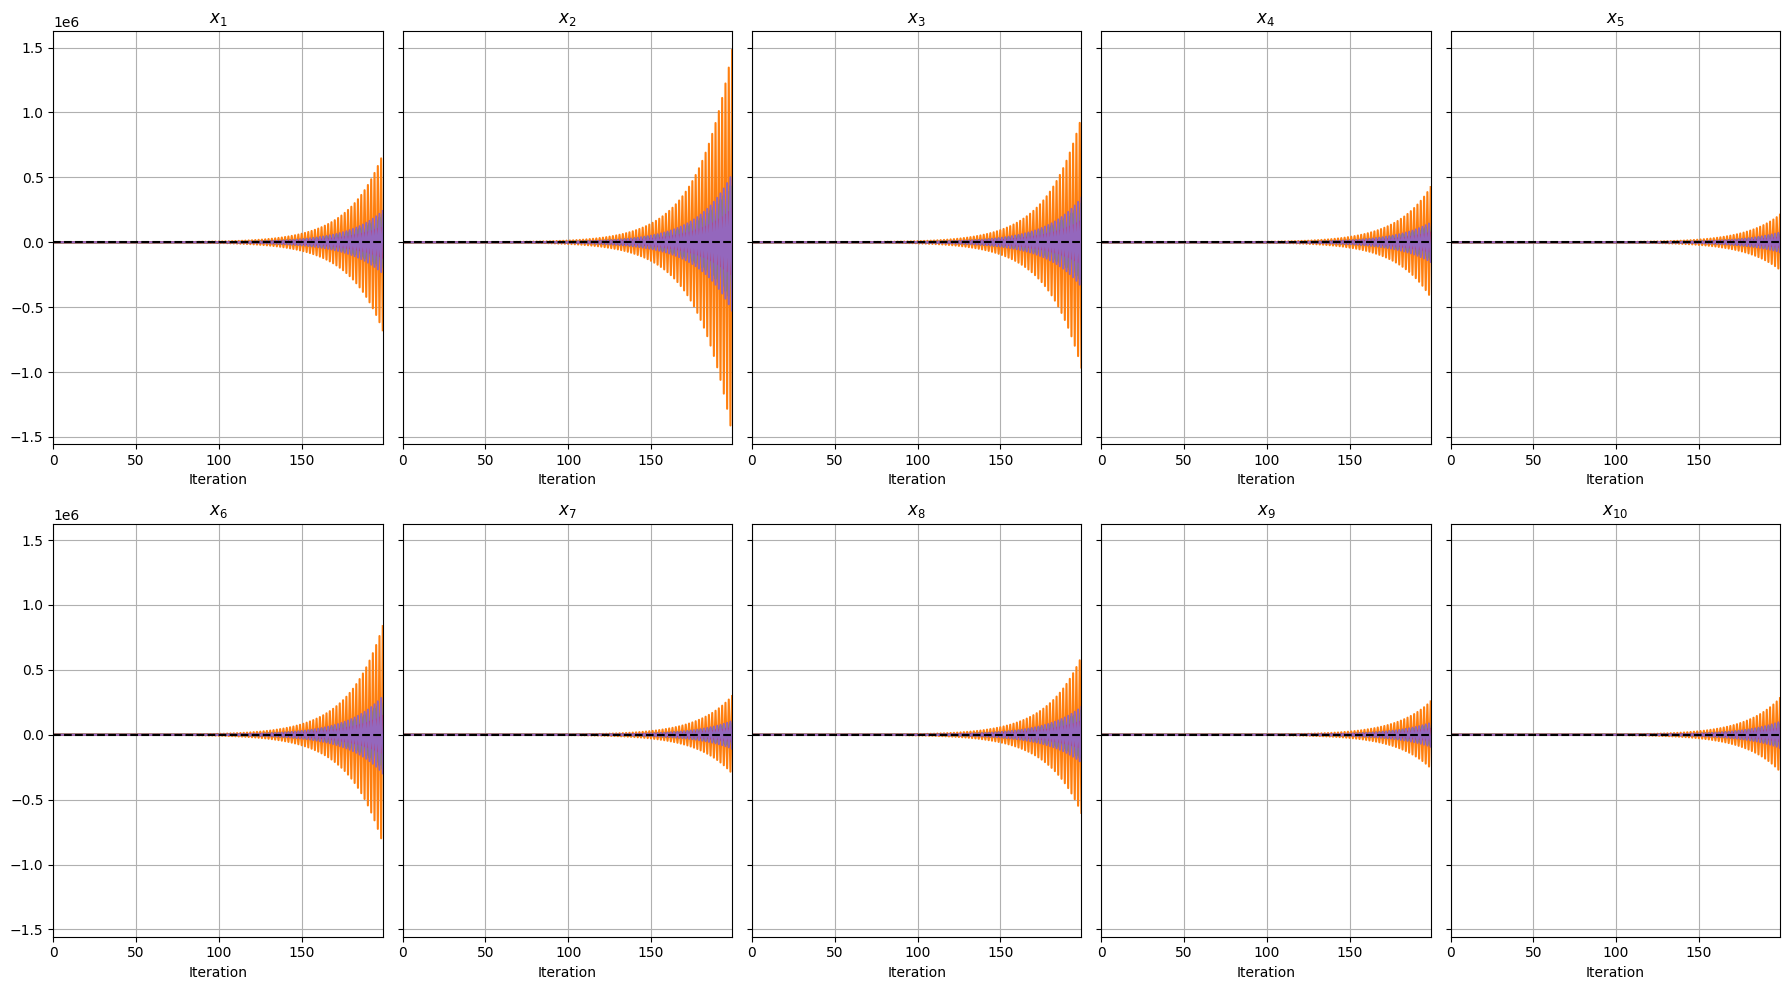

In [220]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    n_cols = 5
    n_rows = (N_STATE + n_cols - 1) // n_cols
    axes1: np.ndarray
    fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), sharey=True)

    initial_states = [baseline_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for i, ax in enumerate(axes1.flatten()):
        ax: maxes.Axes

        for j in NORMAL_NODES:
            states = baseline_data[j]
            ax.plot(states[:, i])

        ax.axhline(mean_states[i], color="k", linestyle="--")

        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.set_title(f"$x_{{{i + 1}}}$")
        ax.grid()

    fig1.tight_layout()

In [221]:
def arepc_node(
    name: str,
    n_state: int,
    alpha: float,
    n_iter: int,
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from numpy import zeros
    from numpy.random import uniform, seed
    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc import ARepC

    agent = ARepC(nh, alpha, eta=0.02, loss_func="qmed", normalization="1.5-entmax")

    x = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    x[0] = uniform(lower_bound, upper_bound, n_state)

    probs = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        x[k + 1] = agent.weighted_mix(x[k])

        # Record normalized weights history
        p = agent.probs
        for j in nh.neighbors:
            probs[j][k] = p[j]

    return x, probs


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        arepc_results = {
            i: pool.apply_async(arepc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        arepc_data = {i: node.get() for i, node in arepc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 158.125.191.134:46369
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '6' joined graph 'default' from 158.125.191.134:46529.
INFO:topolink.graph:Node '7' joined graph 'default' from 158.125.191.134:45625.
INFO:topolink.graph:Node '1' joined graph 'default' from 158.125.191.134:45571.
INFO:topolink.graph:Node '3' joined graph 'default' from 158.125.191.134:45273.
INFO:topolink.graph:Node '11' joined graph 'default' from 158.125.191.134:45757.
INFO:topolink.graph:Node '5' joined graph 'default' from 158.125.191.134:46391.
INFO:topolink.graph:Node '10' joined graph 'default' from 158.125.191.134:44827.
INFO:topolink.graph:Node '8' joined graph 'default' from 158.125.191.134:45407.
INFO:topolink.graph:Node '2' joined graph 'default' from 158.125.191.134:45475.
INFO:topolink.graph:Node '4' joined graph 'default' from 158.125.191.134:46011.
INFO:topolink.graph:Node '9' joined graph 'default' from 15

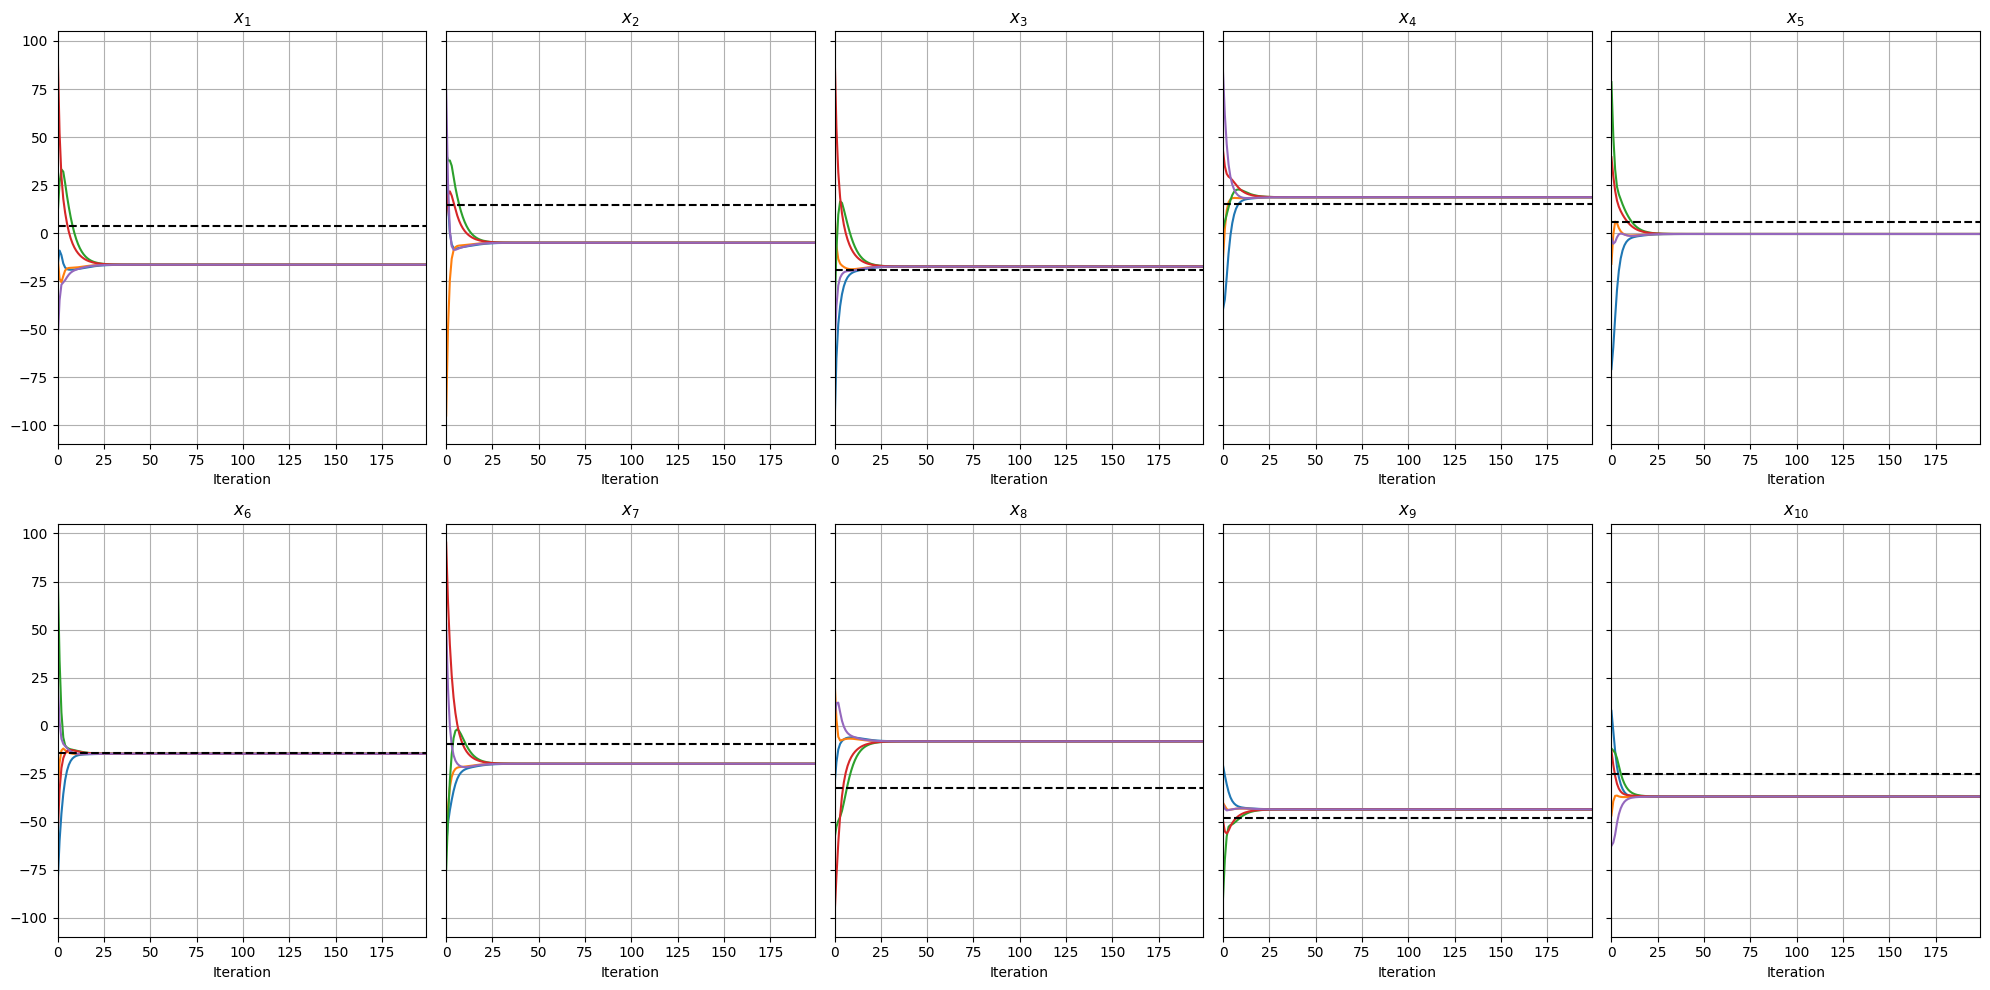

In [222]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    n_cols = 5
    n_rows = (N_STATE + n_cols - 1) // n_cols
    axes2: np.ndarray
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)

    arepc_states = {i: arepc_data[i][0] for i in NORMAL_NODES}

    initial_states = [arepc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.average(initial_states, axis=0)

    for i, ax in enumerate(axes2.flatten()):
        ax: maxes.Axes
        for j in NORMAL_NODES:
            states = arepc_states[j]
            ax.plot(states[:, i])

        ax.axhline(mean_states[i], color="k", linestyle="--")

        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.set_title(f"$x_{{{i + 1}}}$")
        ax.grid()

    fig2.tight_layout()

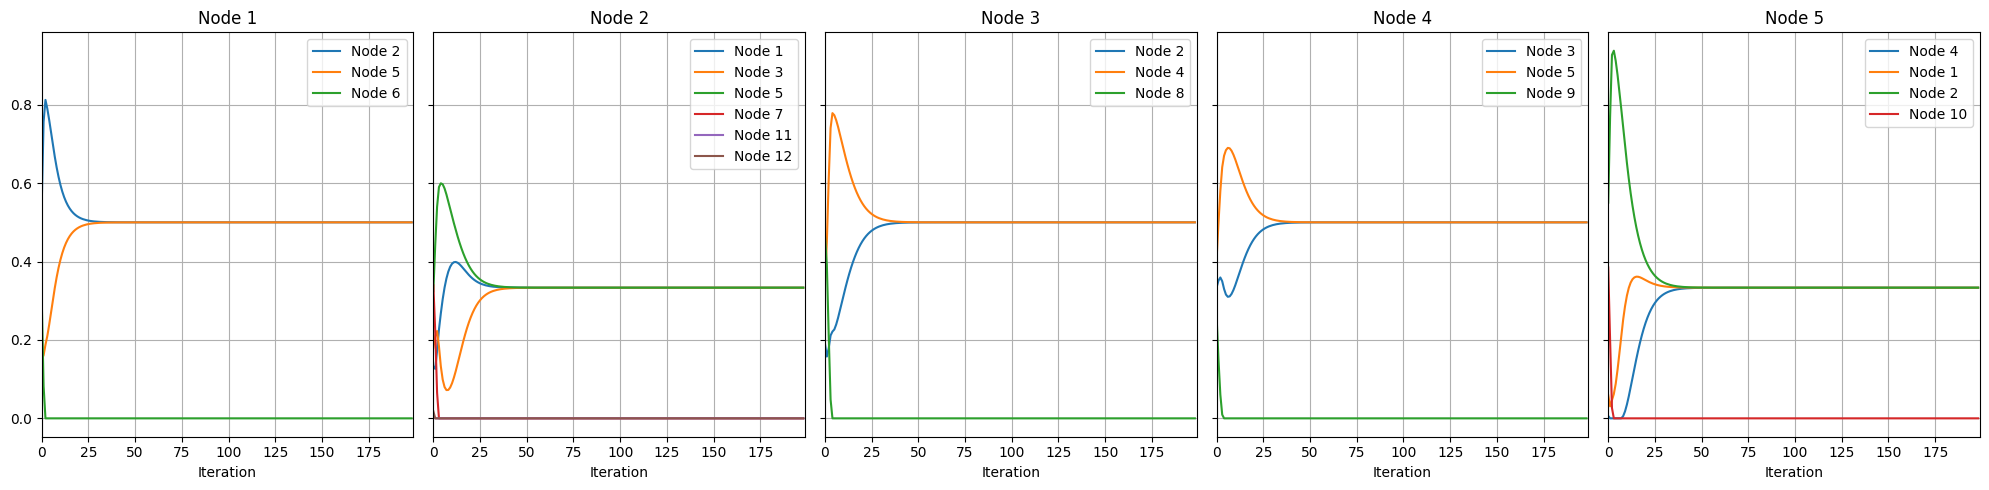

In [223]:
if __name__ == "__main__":
    axes3: tp.Sequence[maxes.Axes]
    fig3, axes3 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    arepc_probs = {i: arepc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes3):
        probs_for_i = arepc_probs[i]
        for j in probs_for_i:
            ax.plot(probs_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig3.tight_layout()

In [224]:
def repc_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> tuple[npt.NDArray[np.float64], dict[str, npt.NDArray[np.float64]]]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import RepC

    agent = RepC(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    reps = {neighbor: zeros(n_iter - 1) for neighbor in nh.neighbors}

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

        # Record normalized weights history
        r = agent.reputations
        for j in nh.neighbors:
            reps[j][k] = r[j]

    return states, reps


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        repc_results = {
            i: pool.apply_async(repc_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        repc_data = {i: node.get() for i, node in repc_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 158.125.191.134:44915
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '10' joined graph 'default' from 158.125.191.134:45475.
INFO:topolink.graph:Node '2' joined graph 'default' from 158.125.191.134:44723.
INFO:topolink.graph:Node '11' joined graph 'default' from 158.125.191.134:45881.
INFO:topolink.graph:Node '3' joined graph 'default' from 158.125.191.134:45953.
INFO:topolink.graph:Node '7' joined graph 'default' from 158.125.191.134:45825.
INFO:topolink.graph:Node '4' joined graph 'default' from 158.125.191.134:45063.
INFO:topolink.graph:Node '12' joined graph 'default' from 158.125.191.134:46381.
INFO:topolink.graph:Node '1' joined graph 'default' from 158.125.191.134:46195.
INFO:topolink.graph:Node '8' joined graph 'default' from 158.125.191.134:45425.
INFO:topolink.graph:Node '9' joined graph 'default' from 158.125.191.134:44893.
INFO:topolink.graph:Node '6' joined graph 'default' from 1

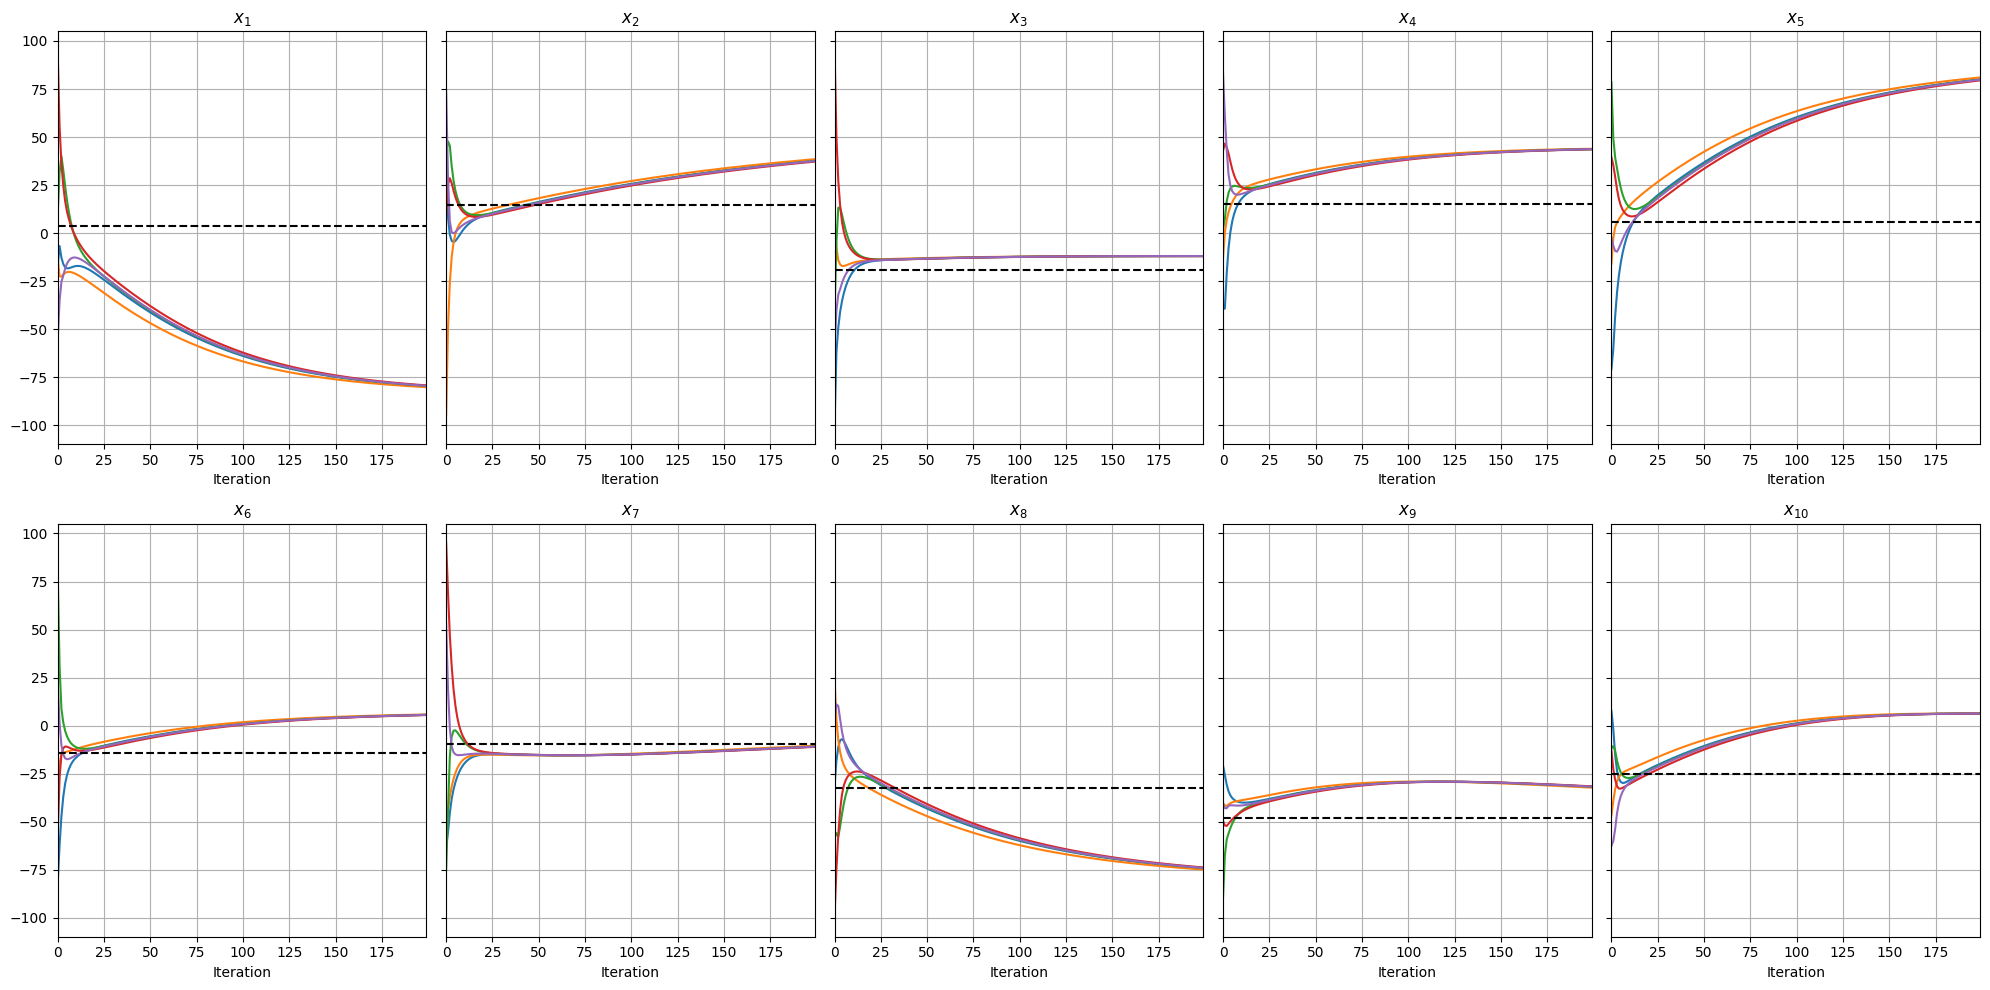

In [225]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    n_cols = 5
    n_rows = (N_STATE + n_cols - 1) // n_cols
    axes4: np.ndarray
    fig4, axes4 = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)

    repc_states = {i: repc_data[i][0] for i in NORMAL_NODES}

    initial_states = [repc_states[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for i, ax in enumerate(axes4.flatten()):
        ax: maxes.Axes
        for j in NORMAL_NODES:
            states = repc_states[j]
            ax.plot(states[:, i])

        ax.axhline(mean_states[i], color="k", linestyle="--")

        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.set_title(f"$x_{{{i + 1}}}$")
        ax.grid()

    fig4.tight_layout()

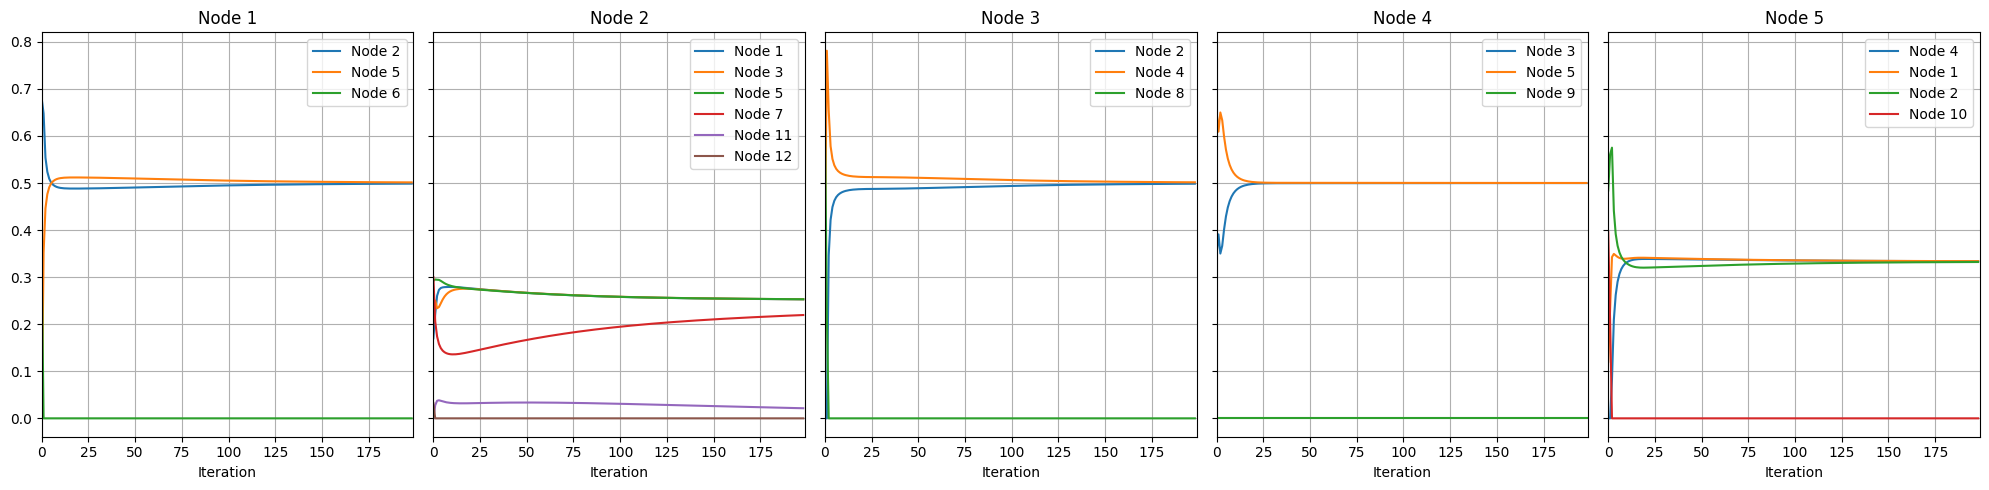

In [226]:
if __name__ == "__main__":
    axes5: tp.Sequence[maxes.Axes]
    fig5, axes5 = plt.subplots(1, N_NORMAL, figsize=(20, 5), sharey=True)

    repc_reps = {i: repc_data[i][1] for i in NORMAL_NODES}

    for i, ax in zip(NORMAL_NODES, axes5):
        reps_for_i = repc_reps[i]
        for j in reps_for_i:
            ax.plot(reps_for_i[j], label=f"Node {j}")
        ax.set_title(f"Node {i}")
        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.legend()
        ax.grid()

    fig5.tight_layout()

In [227]:
def wmsr_node(
    name: str, n_state: int, alpha: float, n_iter: int
) -> npt.NDArray[np.float64]:
    lower_bound = -100.0
    upper_bound = 100.0

    from topolink import NodeHandle

    nh = NodeHandle(name)

    from arepc.baselines import WMSR

    agent = WMSR(nh, alpha, f=1)

    from numpy import zeros
    from numpy.random import uniform, seed

    states = zeros((n_iter, n_state))
    seed(int(name))  # Ensure reproducibility for each node
    states[0] = uniform(lower_bound, upper_bound, n_state)

    for k in range(n_iter - 1):
        # Compute new state
        states[k + 1] = agent.weighted_mix(states[k])

    return states


if __name__ == "__main__":
    with mp.Pool(N_NODES + 1) as pool:
        wmsr_results = {
            i: pool.apply_async(wmsr_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in NORMAL_NODES
        }
        byzantine_results = {
            i: pool.apply_async(byzantine_node, args=(i, N_STATE, ALPHA, N_ITER))
            for i in BYZANTINE_NODES
        }
        pool.apply(graph, args=(NODES, EDGES))

        wmsr_data = {i: node.get() for i, node in wmsr_results.items()}
        byzantine_data = {i: node.get() for i, node in byzantine_results.items()}

INFO:topolink.graph:Graph 'default' running on: 158.125.191.134:45027
INFO:topolink.discovery:Registered graph service with name 'default'
INFO:topolink.graph:Node '6' joined graph 'default' from 158.125.191.134:46521.
INFO:topolink.graph:Node '3' joined graph 'default' from 158.125.191.134:46355.
INFO:topolink.graph:Node '9' joined graph 'default' from 158.125.191.134:45175.
INFO:topolink.graph:Node '1' joined graph 'default' from 158.125.191.134:46655.
INFO:topolink.graph:Node '4' joined graph 'default' from 158.125.191.134:46401.
INFO:topolink.graph:Node '12' joined graph 'default' from 158.125.191.134:46255.
INFO:topolink.graph:Node '5' joined graph 'default' from 158.125.191.134:46513.
INFO:topolink.graph:Node '10' joined graph 'default' from 158.125.191.134:46417.
INFO:topolink.graph:Node '2' joined graph 'default' from 158.125.191.134:44739.
INFO:topolink.graph:Node '11' joined graph 'default' from 158.125.191.134:44867.
INFO:topolink.graph:Node '8' joined graph 'default' from 1

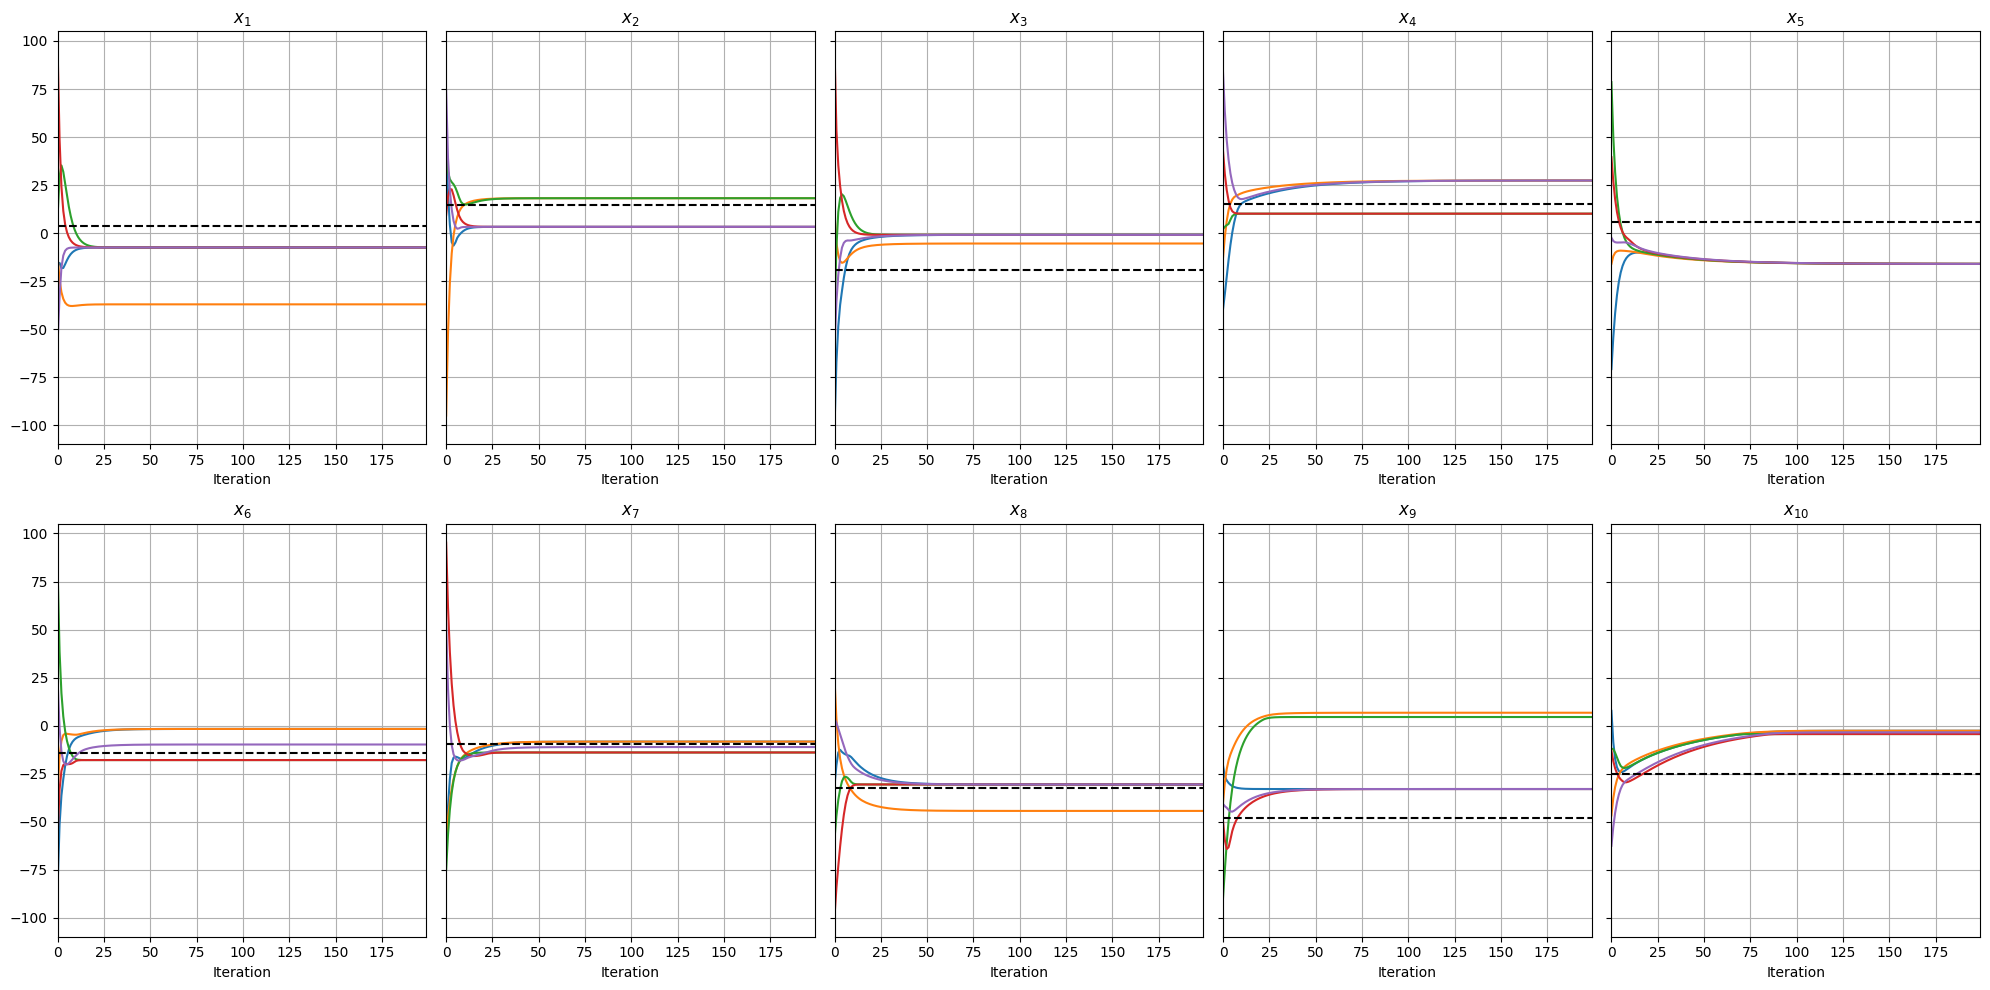

In [228]:
if __name__ == "__main__":
    import typing as tp
    import matplotlib.pyplot as plt
    import matplotlib.axes as maxes

    n_cols = 5
    n_rows = (N_STATE + n_cols - 1) // n_cols
    axes6: np.ndarray
    fig6, axes6 = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows), sharey=True)

    initial_states = [wmsr_data[i][0, :] for i in NORMAL_NODES]
    mean_states: npt.NDArray[np.float64] = np.sum(initial_states, axis=0) / N_NORMAL

    for i, ax in enumerate(axes6.flatten()):
        ax: maxes.Axes
        for j in NORMAL_NODES:
            states = wmsr_data[j]
            ax.plot(states[:, i])

        ax.axhline(mean_states[i], color="k", linestyle="--")

        ax.set_xlabel("Iteration")
        ax.set_xlim(0, N_ITER - 1)
        ax.set_title(f"$x_{{{i + 1}}}$")
        ax.grid()

    fig6.tight_layout()